In [1]:
import torch
from torch import nn
from torch.utils.data import random_split, DataLoader, Subset
from torchvision import datasets
from torchvision.transforms import ToTensor
import numpy as np
import os
import pandas as pd
from torch.utils.data import Dataset
import sklearn
from sklearn.model_selection import train_test_split
from torchvision.transforms import ToTensor, Lambda
import matplotlib.colors as mcolors

from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import StratifiedKFold

import matplotlib.pyplot as plt
import wandb

In [2]:
#This is in place to fix all variables so I can gauge how effective changes are 

torch.manual_seed(42)
np.random.seed(42)

# Make training deterministic
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


#### **Put data into a database**

In [3]:

class CustomDataset(Dataset):
    def __init__(self, labels, data, dir, transform=None, target_transform=None):
        self.labels = labels
        self.data = data
        self.dir = dir
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        data = self.data[idx]
        label = self.labels[idx]
        if self.transform:
            data = self.transform(data)
        if self.target_transform:
            label = self.target_transform(label)
                    
        data = torch.from_numpy(data).type(torch.float)
        
        return data, label

In [4]:
# Create the dataset
data_dir = 'data.csv'
labels_file = 'data_labels.csv'

x_data  = np.loadtxt('data.csv', delimiter=',', dtype=float, skiprows = 1)
y_data  = np.loadtxt('data_labels.csv', delimiter=',', dtype=float, skiprows = 1).astype(np.int64)

#Feature transform: log the x-data
x_data[x_data <= 0] = 1e-4 #replace 0s by small numbers so log doesn't go to inf
x_data[:2, :] = np.log10(x_data[:2, :])
#Log only the velocities 
# x_data[1, :] = np.log10(x_data[1, :])

print(np.shape(x_data), np.shape(y_data))
#Save the original input for later 
x_data_og = x_data
X_train, X_test, y_train, y_test = train_test_split(x_data.T, y_data, test_size=0.20, stratify = y_data, random_state=42)

# Define the transform - One-Hot encoded
transform = None
target_transform = Lambda(lambda y: torch.zeros(3, dtype=torch.float).scatter_(0, torch.tensor(y), value=1))

# Create separate datasets for train and test
train_dataset = CustomDataset(dir=data_dir, labels = y_train, data = X_train, transform=transform, target_transform = target_transform)
test_dataset = CustomDataset(dir=data_dir, labels = y_test, data = X_test, transform=transform, target_transform = target_transform)


#Take this out for final iteration, it is here to make sure data is shuffled the same each time
g = torch.Generator()
g.manual_seed(42)

train_dataloader = DataLoader(train_dataset, batch_size=128, shuffle=True, generator=g)
test_dataloader = DataLoader(test_dataset, batch_size=128, shuffle=False, generator=g)
#TODO: Think about batching

for batch_data, batch_labels in train_dataloader:
    print("Batch data shape:", batch_data.shape)   # Correct way to check shape
    print("Batch labels shape:", batch_labels.shape)


(4, 14187) (14187,)
Batch data shape: torch.Size([128, 4])
Batch labels shape: torch.Size([128, 3])
Batch data shape: torch.Size([128, 4])
Batch labels shape: torch.Size([128, 3])
Batch data shape: torch.Size([128, 4])
Batch labels shape: torch.Size([128, 3])
Batch data shape: torch.Size([128, 4])
Batch labels shape: torch.Size([128, 3])
Batch data shape: torch.Size([128, 4])
Batch labels shape: torch.Size([128, 3])
Batch data shape: torch.Size([128, 4])
Batch labels shape: torch.Size([128, 3])
Batch data shape: torch.Size([128, 4])
Batch labels shape: torch.Size([128, 3])
Batch data shape: torch.Size([128, 4])
Batch labels shape: torch.Size([128, 3])
Batch data shape: torch.Size([128, 4])
Batch labels shape: torch.Size([128, 3])
Batch data shape: torch.Size([128, 4])
Batch labels shape: torch.Size([128, 3])
Batch data shape: torch.Size([128, 4])
Batch labels shape: torch.Size([128, 3])
Batch data shape: torch.Size([128, 4])
Batch labels shape: torch.Size([128, 3])
Batch data shape: to

### **Build Neural Network**

In [5]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(4, 100),
            nn.ReLU(),
            nn.Linear(100, 100),
            nn.ReLU(),
            nn.Linear(100, 100),
            nn.ReLU(),
            nn.Linear(100, 3),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

In [5]:


def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for X, y in dataloader:

        # Compute prediction error
        pred = model(X)

        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        # Log metrics to wandb.
        accuracy = (pred.argmax(dim = 1) == y.argmax(dim = 1)).type(torch.float).sum().item()
        accuracy /= size
        y = y.argmax(dim=1)
        balanced_acc = balanced_accuracy_score(y.numpy(), pred.argmax(dim = 1).numpy())
        
        run.log({"train_acc": 100*accuracy, "train_balanced_acc": 100*balanced_acc, "train_loss": loss.item()})

def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    y_true = [] # Store labels for balanced accuracy
    y_pred = []  # Store labels for balanced accuracy
    with torch.no_grad():
        for X, y in dataloader:
            # X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            # print(pred.shape, y.shape)
            correct += (pred.argmax(dim = 1) == y.argmax(dim = 1)).type(torch.float).sum().item()
            # Store predictions and true labels
            y_true.extend(y.argmax(dim = 1).numpy())  # Convert tensors to NumPy
            y_pred.extend(pred.argmax(dim = 1).numpy())

    test_loss /= num_batches
    correct /= size
    balanced_acc = balanced_accuracy_score(y_true, y_pred)
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Balanced Accuracy: {(100*balanced_acc):>0.1f}%, Avg loss: {test_loss:>8f} \n")
    
    # Log metrics to wandb.
    run.log({"test_acc": 100*correct, "test_balanced_acc": 100*balanced_acc, "test_loss": test_loss})

    return test_loss



In [6]:
# Start a new wandb run to track this script.
run = wandb.init(
    # Set the wandb entity where your project will be logged (generally your team name).
    entity="elena-gonzalez-northwestern-university",
    # Set the wandb project where this run will be logged.
    project="ML_SPH_NN",
    name="W100_l3_b128_regression",
    # Track hyperparameters and run metadata.
    config={
        "learning_rate": 0.1,
        "architecture": "NN",
        "dataset": "FB",
        "epochs": 1000,
        "width": 1000, 
        "layers": 3,
        "batch_size": 128
    },
)


wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: elena-gonzalez (elena-gonzalez-northwestern-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [7]:
epochs = 1000
k_folds = 5
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

# Initialize list for storing validation loss for plotting
val_loss_history = [[] for _ in range(k_folds)]  # Store per-fold validation losses


for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    
    # Subset dataloaders
    train_loader = DataLoader(Subset(train_dataset, train_idx), batch_size=128, shuffle=True)
    val_loader   = DataLoader(Subset(train_dataset, val_idx), batch_size=128, shuffle=False)

    model = NeuralNetwork()
    model = model.float()
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

    # Log fold number
    # run.log({"fold": fold+1})

    for t in range(epochs):
        print(f"Epoch {t+1}\n-------------------------------")
        train(train_loader, model, loss_fn, optimizer)
        val_loss = test(val_loader, model, loss_fn)

        # Log validation loss for this fold and epoch to WandB
        # run.log({"epoch": t+1, "val_loss": val_loss, "fold": fold+1})

        # Store validation loss for later analysis (per fold)
        val_loss_history[fold].append(val_loss)

print("Done!")


# After all folds are done, calculate the average validation loss across all folds
avg_val_loss_per_fold = [sum(fold_losses)/len(fold_losses) for fold_losses in val_loss_history]
overall_avg_val_loss = sum(avg_val_loss_per_fold) / len(avg_val_loss_per_fold)

# Log overall average validation loss to WandB for final reporting
wandb.log({"overall_avg_val_loss": overall_avg_val_loss})

# Log the average validation loss (TODO: CHECK how good this is:)
avg_val_loss_per_epoch = np.mean(val_loss_history, axis=0)  # shape: [epochs]
std_val_loss_per_epoch = np.std(val_loss_history, axis=0)

# Log to WandB in final run
for epoch, (mean_loss, std_loss) in enumerate(zip(avg_val_loss_per_epoch, std_val_loss_per_epoch), 1):
    wandb.log({"avg_val_loss": mean_loss, "std_val_loss": std_loss, "epoch": epoch})

# Finish the run and upload any remaining data.
run.finish()

#TODO" I need to save each model


Epoch 1
-------------------------------
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Test Error: 
 Accuracy: 86.0%, Balanced Accuracy: 60.7%, Avg loss: 0.521675 

Epoch 2
-------------------------------
Test Error: 
 Accuracy: 86.7%, Balanced Accuracy: 61.2%, Avg loss: 0.431832 

Epoch 3
-------------------------------
Test Error: 
 Accuracy: 87.0%, Balanced Accuracy: 61.7%, Avg loss: 0.396990 

Epoch 4
-------------------------------
Test Error: 
 Accuracy: 87.0%, Balanced Accuracy: 68.3%, Avg loss: 0.377432 

Epoch 5
-------------------------------
Test Error: 
 Accuracy: 89.2%, Balanced Accuracy: 73.6%, Avg loss: 0.337756 

Epoch 6
-------------------------------
Test Error: 
 Accuracy: 86.9%, Balanced Accuracy: 61.3%, Avg loss: 0.329671 

Epoch 7
-------------------------------
Te

/Users/elenagonzalez/miniconda3/envs/ML/lib/python3.9/site-packages/sklearn/metrics/_classification.py:2480: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Test Error: 
 Accuracy: 94.4%, Balanced Accuracy: 86.9%, Avg loss: 0.131996 

Epoch 66
-------------------------------
Test Error: 
 Accuracy: 92.8%, Balanced Accuracy: 81.9%, Avg loss: 0.160881 

Epoch 67
-------------------------------
Test Error: 
 Accuracy: 96.2%, Balanced Accuracy: 93.4%, Avg loss: 0.106091 

Epoch 68
-------------------------------
Test Error: 
 Accuracy: 92.2%, Balanced Accuracy: 77.3%, Avg loss: 0.167247 

Epoch 69
-------------------------------
Test Error: 
 Accuracy: 93.0%, Balanced Accuracy: 81.8%, Avg loss: 0.173844 

Epoch 70
-------------------------------
Test Error: 
 Accuracy: 94.1%, Balanced Accuracy: 95.2%, Avg loss: 0.145482 

Epoch 71
-------------------------------
Test Error: 
 Accuracy: 95.2%, Balanced Accuracy: 94.0%, Avg loss: 0.127290 

Epoch 72
-------------------------------
Test Error: 
 Accuracy: 94.9%, Balanced Accuracy: 88.4%, Avg loss: 0.120579 

Epoch 73
-------------------------------
Test Error: 
 Accuracy: 96.3%, Balanced Accuracy

/Users/elenagonzalez/miniconda3/envs/ML/lib/python3.9/site-packages/sklearn/metrics/_classification.py:2480: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Test Error: 
 Accuracy: 96.5%, Balanced Accuracy: 92.6%, Avg loss: 0.089661 

Epoch 108
-------------------------------
Test Error: 
 Accuracy: 96.2%, Balanced Accuracy: 91.5%, Avg loss: 0.093994 

Epoch 109
-------------------------------
Test Error: 
 Accuracy: 95.5%, Balanced Accuracy: 90.7%, Avg loss: 0.124950 

Epoch 110
-------------------------------
Test Error: 
 Accuracy: 95.7%, Balanced Accuracy: 90.5%, Avg loss: 0.098788 

Epoch 111
-------------------------------
Test Error: 
 Accuracy: 91.1%, Balanced Accuracy: 72.4%, Avg loss: 0.228596 

Epoch 112
-------------------------------
Test Error: 
 Accuracy: 96.5%, Balanced Accuracy: 92.7%, Avg loss: 0.093077 

Epoch 113
-------------------------------
Test Error: 
 Accuracy: 92.4%, Balanced Accuracy: 93.6%, Avg loss: 0.171360 

Epoch 114
-------------------------------
Test Error: 
 Accuracy: 96.9%, Balanced Accuracy: 93.4%, Avg loss: 0.083637 

Epoch 115
-------------------------------
Test Error: 
 Accuracy: 96.0%, Balanced 

...

/Users/elenagonzalez/miniconda3/envs/ML/lib/python3.9/site-packages/sklearn/metrics/_classification.py:2480: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Test Error: 
 Accuracy: 96.0%, Balanced Accuracy: 94.7%, Avg loss: 0.113024 

Epoch 757
-------------------------------
Test Error: 
 Accuracy: 96.4%, Balanced Accuracy: 95.2%, Avg loss: 0.094862 

Epoch 758
-------------------------------
Test Error: 
 Accuracy: 96.5%, Balanced Accuracy: 94.0%, Avg loss: 0.113708 

Epoch 759
-------------------------------
Test Error: 
 Accuracy: 94.9%, Balanced Accuracy: 90.5%, Avg loss: 0.167771 

Epoch 760
-------------------------------
Test Error: 
 Accuracy: 96.6%, Balanced Accuracy: 93.7%, Avg loss: 0.118184 

Epoch 761
-------------------------------
Test Error: 
 Accuracy: 94.5%, Balanced Accuracy: 85.6%, Avg loss: 0.180188 

Epoch 762
-------------------------------
Test Error: 
 Accuracy: 96.1%, Balanced Accuracy: 92.8%, Avg loss: 0.122141 

Epoch 763
-------------------------------
Test Error: 
 Accuracy: 96.6%, Balanced Accuracy: 93.5%, Avg loss: 0.099560 

Epoch 764
-------------------------------
Test Error: 
 Accuracy: 94.3%, Balanced 

/Users/elenagonzalez/miniconda3/envs/ML/lib/python3.9/site-packages/sklearn/metrics/_classification.py:2480: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Test Error: 
 Accuracy: 95.7%, Balanced Accuracy: 90.3%, Avg loss: 0.147486 

Epoch 993
-------------------------------
Test Error: 
 Accuracy: 96.3%, Balanced Accuracy: 94.6%, Avg loss: 0.108722 

Epoch 994
-------------------------------
Test Error: 
 Accuracy: 96.5%, Balanced Accuracy: 95.4%, Avg loss: 0.114280 

Epoch 995
-------------------------------
Test Error: 
 Accuracy: 96.7%, Balanced Accuracy: 93.9%, Avg loss: 0.112340 

Epoch 996
-------------------------------
Test Error: 
 Accuracy: 96.3%, Balanced Accuracy: 92.4%, Avg loss: 0.127668 

Epoch 997
-------------------------------
Test Error: 
 Accuracy: 96.2%, Balanced Accuracy: 93.3%, Avg loss: 0.114122 

Epoch 998
-------------------------------
Test Error: 
 Accuracy: 95.3%, Balanced Accuracy: 90.5%, Avg loss: 0.156229 

Epoch 999
-------------------------------
Test Error: 
 Accuracy: 95.7%, Balanced Accuracy: 89.3%, Avg loss: 0.140515 

Epoch 1000
-------------------------------
Test Error: 
 Accuracy: 96.3%, Balanced

avg_val_loss,█▃▂▂▂▃▁▁▁▂▂▁▁▂▁▁▁▁▃▁▁▁▃▁▃▁▂▁▂▂▂▂▂▁▁▃▃▂▁▁
epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇███
overall_avg_val_loss,▁
std_val_loss,▂▂▁▃▁▁▁▃▁▁▂▁▂█▁▁▂▂▂▂▃▂▁▂▁▂▂▃▁▂▂▂▄▂▂▁▁▂▁▅
test_acc,▇▇██▆█▁▆▇▇▁▅▇▅▄▇▇▇▆▇▄▅▇▇██▇▇▅▆▆▆▇▆▆▇▆▆▆▆
test_balanced_acc,▇▇▂▇▇▇▇▇▅▆▇▇▇███▁▆▇▇▆▇█▆▇▇▇███▇▇▇█▇▇▅█▇▇
test_loss,▂▁▁▁▁▂▁▁▁▂▂▁▁▃▂▃▁▁▁▁▁▂▂▂▁▁▁▁▁▁▁█▂▇▂▂▂▂▁▂
train_acc,▆▆▇▇▇██▇█▅█▇█▇▇▅▆▄▁▆█▇▇██▇▇█▇██▇██▄▇▄▇█▇
train_balanced_acc,▃█▆▅███▇▅▇▇██▇▇▇█▁▇███▇███▇▆█▇███▇█▇▆▇██
train_loss,▂▃▂▄▂▂▂▁▂▂▂▁▂▂▂█▄▂▁▂▂▁▂▁▁▂▆▂▂▂▁▁▂▄▄▂▁▁▂▂
avg_val_loss,0.12872


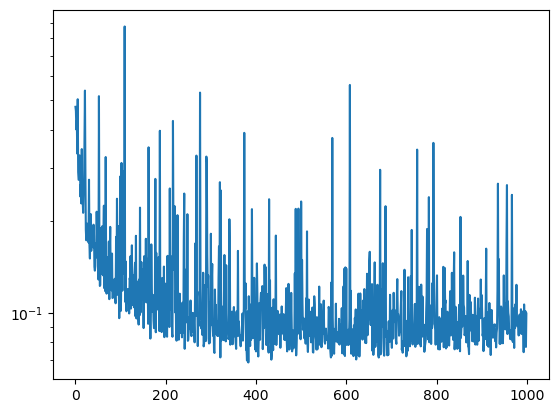

In [58]:
plt.plot(loss_history)
plt.yscale('log')


In [44]:
import requests
from pathlib import Path 

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

helper_functions.py already exists, skipping download


In [45]:

train_dataset.data = torch.from_numpy(train_dataset.data).type(torch.float)
train_dataset.labels = torch.from_numpy(train_dataset.labels).type(torch.float)
test_dataset.data = torch.from_numpy(test_dataset.data).type(torch.float)
test_dataset.labels = torch.from_numpy(test_dataset.labels).type(torch.float)

if isinstance(train_dataset.data, np.ndarray):
    print("X is a NumPy array")


[[1.         1.         1.         ... 0.4        0.5        0.7       ]
 [1.         1.         1.         ... 1.70000085 2.         2.5       ]]
(2, 290)


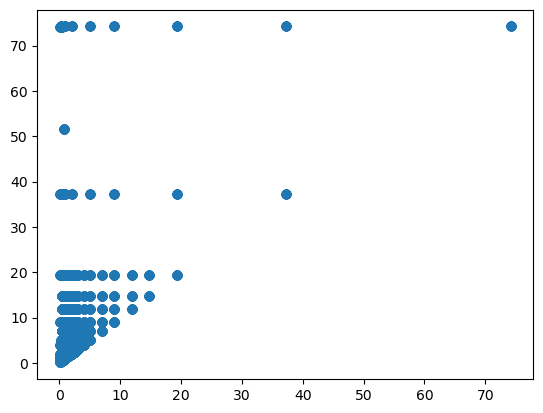

In [46]:
masses = x_data_og[2:,:]
masses[1, :] = masses[0, :] / masses[1, :]

plt.scatter(masses[0, :], masses[1, :])
print((masses))
unique_rows = np.unique(masses, axis=1)
print((np.shape(unique_rows)))

In [47]:
def plot_4d_decision_boundary(model, X_train, y_train, X_test, y_test, feature_idx=(0, 1), fixed_values={}, labels = []):
    """
    Plots the decision boundary for a PyTorch model using a 2D slice of a higher-dimensional space.
    
    Parameters:
    - model: Trained PyTorch model.
    -X, y:  data and labels.
    - feature_idx: Tuple (i, j) specifying which two features to plot.
    - fixed_values: Dictionary {feature_index: value} for fixing other dimensions.
    labels = list of strings 
    """

    # Step 1: Filter train and test data based on fixed_values
    
    train_mask= np.all([np.isclose(X_train[:, k], v, rtol = 0.09) for k, v in fixed_values.items()], axis=0)
    test_mask= np.all([np.isclose(X_test[:, k], v, rtol = 0.09) for k, v in fixed_values.items()], axis=0) 

    X_train_filtered, y_train_filtered = X_train[train_mask], y_train[train_mask]
    X_test_filtered, y_test_filtered = X_test[test_mask], y_test[test_mask]

    # Step 2: Create a meshgrid for the chosen two features
    x_min, x_max = X_train[:, feature_idx[0]].min() - 0.1, X_train[:, feature_idx[0]].max() + 0.1
    y_min, y_max = X_train[:, feature_idx[1]].min() - 0.1, X_train[:, feature_idx[1]].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

    # Step 3: Construct full-dimensional input space for predictions
    X_vis = torch.zeros((xx.ravel().shape[0], X_train.shape[1]), dtype=torch.float32)
    X_vis[:, feature_idx[0]] = torch.tensor(xx.ravel(), dtype=torch.float32)
    X_vis[:, feature_idx[1]] = torch.tensor(yy.ravel(), dtype=torch.float32)

    # Assign fixed values to other dimensions
    for k, v in fixed_values.items():
        X_vis[:, k] = v

    # Step 4: Predict labels for meshgrid
    model.eval()
    with torch.no_grad():
        Z = model(X_vis).argmax(dim=1).numpy()
    Z = Z.reshape(xx.shape)

    # Normalize color mapping to match the scatter points and contour
    cmap = plt.cm.coolwarm  # Set the same colormap
    norm = mcolors.Normalize(vmin=y_train.min(), vmax=y_train.max())  # Normalize colors

    # Step 5: Plot decision boundary
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap, norm=norm)
    plt.scatter(X_train_filtered[:, feature_idx[0]], X_train_filtered[:, feature_idx[1]], c=y_train_filtered, cmap='coolwarm', edgecolor="k", marker='o', label = 'Train')
    plt.scatter(X_test_filtered[:, feature_idx[0]], X_test_filtered[:, feature_idx[1]], c=y_test_filtered, cmap='coolwarm', edgecolor="k", marker='x', label = 'Test')
    plt.xlabel(f" {labels[0]}")
    plt.ylabel(f" {labels[1]}")
    plt.legend()
    plt.title(f"NN: Decision Boundary Mass1 = {labels[2]} Msun , Mass2 = {labels[3]}Msun")
    plt.show()

In [48]:
# plot_4d_decision_boundary(model, train_dataset.data, train_dataset.labels, test_dataset.data, test_dataset.labels,feature_idx=(0, 1), fixed_values={2: 0.2, 3: round(0.2/74.21,2)}, labels = labels)

[1. 1.]


/var/folders/4h/5kpc_p3153q1gx8btc9x_3mc0000gn/T/ipykernel_37433/1235980194.py:48: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_test_filtered[:, feature_idx[0]], X_test_filtered[:, feature_idx[1]], c=y_test_filtered, cmap='coolwarm', edgecolor="k", marker='x', label = 'Test')


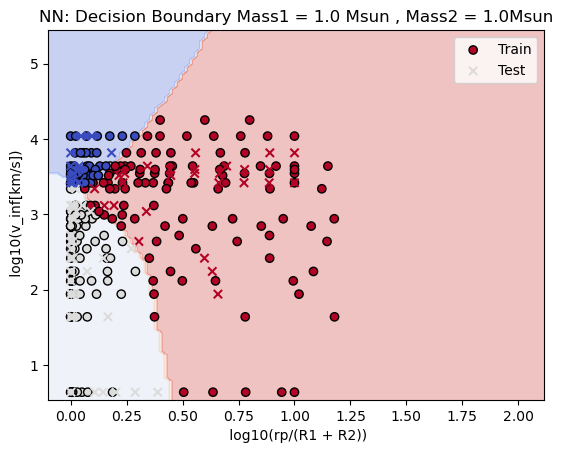

In [49]:

# unique_rows = unique_rows.T
unique_rows = np.array([[1.0,1.0]])
for unique in unique_rows:
    print(unique)
    Mass1 = unique[0]
    Mass2 = unique[1]
    # labels = ['log10(b[RSUN])', 'log10(v_inf[km/s])', str(Mass1), str(round(Mass2,2))]
    labels = ['log10(rp/(R1 + R2))', 'log10(v_inf[km/s])', str(Mass1), str(round(Mass2,2))]

    plot_4d_decision_boundary(model, train_dataset.data, train_dataset.labels, test_dataset.data, test_dataset.labels,feature_idx=(0, 1), fixed_values={2: Mass1, 3: Mass1/Mass2}, labels = labels)